# Contribution scores of DeepDanio

This notebook shows how to load and plot the contribution scores of a cell state-specific peak.

Contribution scores indicate how much each base of a sequence contributes to the predicted accessibility in a given cell state. They were computed with DeepSHAP on the ensemble of the models trained on chromosome splits 0, 1, and 2, using 10 dinucleotide-shuffled versions of each sequence as references. Positive contributions increase predicted accessibility, and negative ones decrease it. The contributions of all bases of a sequence add up to its predicted accessibility minus the average prediction on its shuffled references.

Contributions are available for 162,262 cell state-specific peaks: the 10,000 peaks with the highest predicted specificity in each cell state, combined. Each peak has contributions in all 95 cell states.

Steps:
1. Choose a peak and the cell states to plot.
2. Load the peak's sequence, measured accessibility, and contributions.
3. Plot the total contribution per cell state.
4. Plot contributions of each base, for the whole peak and for a region of interest.

Requirements:
- Contribution scores (`data/contributions/contributions.h5`), downloaded with `analysis/motif_discovery/download_results.py`.
- Processed training data, downloaded with `data/download_data.py`, for peak sequences and measured accessibility.

## Imports

`deepdanio` modules used here:
- `definitions`: paths to data files, and cell state information such as `CELL_STATES` and `DIFFERENTIATION_PATHS`.
- `data`: loads peak sequences, measured accessibility, and contribution scores.
- `plot`: plotting functions for values across cell states and for contribution scores.

In [1]:
import h5py
import pandas
from matplotlib import pyplot

from deepdanio import data, definitions, plot

## Settings

Edit this cell to choose the peak and the cell states to plot.

- `PEAK_ID`: peak identifier, with format `'{chromosome number}-{start}-{end}'` in zero-based, half-open GRCz11 coordinates. See "Finding peaks with contributions" below to search for peaks in a genomic region.
- `CELL_STATES_TO_PLOT`: cell states whose contributions are plotted base by base. Any list of names from `definitions.CELL_STATES` works. `definitions.DIFFERENTIATION_PATHS` contains the cell states along the differentiation trajectory from high cells to each 6-somite cell state, indexed by cell type, e.g. `'adaxial cells'` or `'ysl'`.
- `ZOOM_START`, `ZOOM_END`: region within the peak to plot in detail, as zero-based, half-open positions relative to the peak start.

The default peak, on chromosome 5, is among the most specific to adaxial cells at the 6-somite stage, and is also accessible in somites and presomitic mesoderm (PSM).

In [2]:
PEAK_ID = '5-25695926-25696426'
CELL_STATES_TO_PLOT = definitions.DIFFERENTIATION_PATHS['adaxial cells']
ZOOM_START = 170
ZOOM_END = 310

## Finding peaks with contributions

The cell below lists the peaks with contributions that overlap a genomic region, as `'chr:start-end'` in zero-based, half-open coordinates. Copy one of the resulting IDs to `PEAK_ID` above. This step is optional.

In [3]:
region = 'chr5:25690000-25700000'

chrom, coords = region.split(':')
start, end = [int(c.replace(',', '')) for c in coords.split('-')]
with h5py.File(definitions.CONTRIBUTIONS_PATH, 'r') as f:
    contrib_peak_ids = f['peak_id'].asstr()[:]
peak_coords = pandas.Series(contrib_peak_ids).str.split('-', expand=True).astype(int)
peak_coords.columns = ['chr', 'start', 'end']
peak_coords.index = contrib_peak_ids
overlapping = (peak_coords['chr'] == int(chrom.removeprefix('chr'))) & (peak_coords['start'] < end) & (peak_coords['end'] > start)
print(f"{len(contrib_peak_ids):,} peaks with contributions, {overlapping.sum()} in {region}:")
print('\n'.join(peak_coords.index[overlapping]))

162,262 peaks with contributions, 3 in chr5:25690000-25700000:
5-25690809-25691309
5-25694571-25695071
5-25695926-25696426


## Load peak data

Loads the sequence and measured accessibility of the peak from the processed training data, and its contributions in all cell states. `data.load_contributions` returns actual contributions, i.e. one value per base, with shape (n_peaks, n_cell_states, 500). Here they are stored in a DataFrame with one row per cell state and one column per position.

Measured accessibility is log10-transformed CPM, quantile normalized across cell states, the units the model was trained on.

In [4]:
peaks_df, signal_df = data.load_training_data('peaks')
seq = peaks_df.loc[PEAK_ID, 'sequence']
signal = signal_df.loc[PEAK_ID]

contribs = data.load_contributions([PEAK_ID])[0]
contribs = pandas.DataFrame(contribs, index=definitions.CELL_STATES)
print(f"{PEAK_ID}: {peaks_df.loc[PEAK_ID, 'chr']}:{peaks_df.loc[PEAK_ID, 'start']}-{peaks_df.loc[PEAK_ID, 'end']}")
signal.sort_values(ascending=False).head(10)

5-25695926-25696426: chr5:25695926-25696426


adaxial cells(6somite)             1.761372
somite(6somite)                    1.703552
adaxial cells(bud)                 1.675760
psm(bud)                           1.444854
adaxial cells(75epi)               1.350982
psm(6somite)                       1.245033
psm(75epi)                         1.079598
lateral plate mesoderm(75epi)      0.967557
differentiating neuron(6somite)    0.863012
ventrolateral mesoderm(shield)     0.801341
Name: 5-25695926-25696426, dtype: float32

## Total contribution per cell state

The sum of a peak's contributions in a cell state equals its predicted accessibility in that cell state, relative to the average prediction on shuffled versions of the sequence. Plotting it along the differentiation trajectory next to measured accessibility shows in which cell states the sequence is predicted to drive accessibility. See `examples/predict.ipynb` for details about these plots.

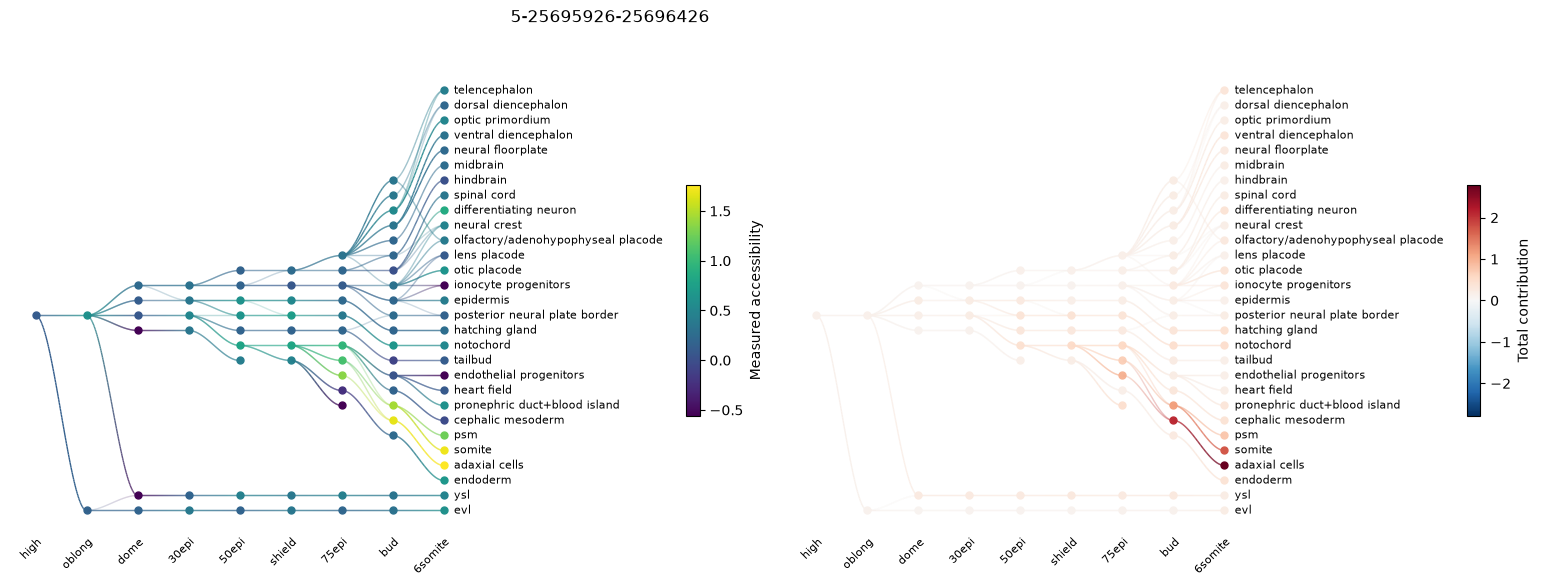

In [5]:
# Colormap centered at zero, so that positive and negative contributions are red and blue
total_contribs = contribs.sum(axis=1)
max_abs_total = total_contribs.abs().max()

fig, axes = pyplot.subplots(1, 2, figsize=(16, 6), gridspec_kw={'wspace': 0.7})
plot.trajectory(
    cell_state_vals=signal,
    colorbar=True,
    colorbar_label='Measured accessibility',
    cell_state_labels='final',
    ax=axes[0],
)
plot.trajectory(
    cell_state_vals=total_contribs,
    cmap='RdBu_r',
    vmin=-max_abs_total,
    vmax=max_abs_total,
    colorbar=True,
    colorbar_label='Total contribution',
    cell_state_labels='final',
    ax=axes[1],
)
fig.suptitle(PEAK_ID)
pyplot.show()

## Contributions of each base

`plot.contribution_logos` shows the peak sequence on top, followed by the contributions in each cell state as a sequence logo, where the height of each base is its contribution. All cell states share the same y axis. Bases forming transcription factor motifs often appear as groups of high contributions.

Arguments to customize the plot:
- `start`, `end`: region of the peak to plot.
- `ylabel_orientation`: `'horizontal'` (default) or `'vertical'` cell state labels.
- `figsize`: figure size.

The function returns the figure. To save it, use e.g. `fig.savefig('contributions.pdf', bbox_inches='tight')`.

### Whole peak

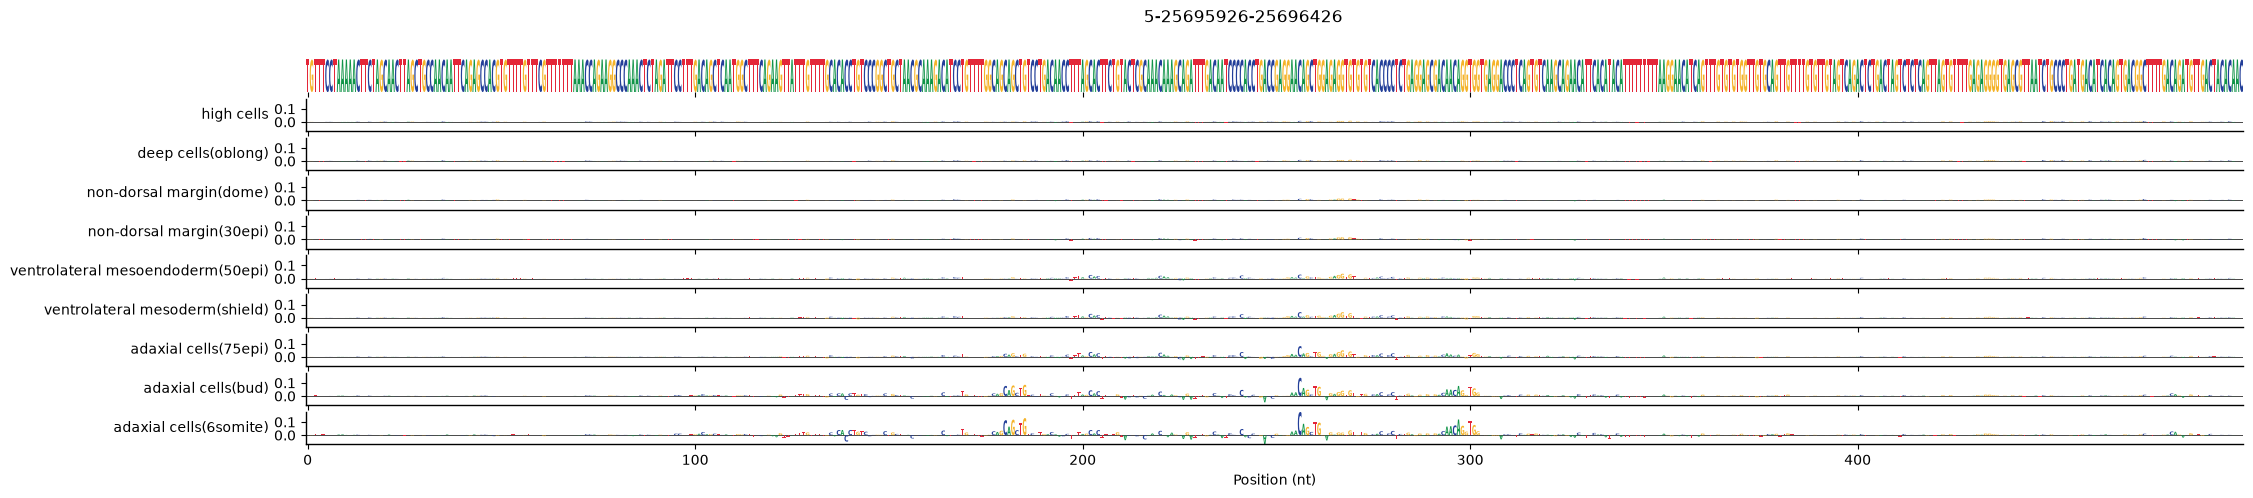

In [6]:
fig = plot.contribution_logos(seq, contribs.loc[CELL_STATES_TO_PLOT].values, CELL_STATES_TO_PLOT)
fig.suptitle(PEAK_ID)
pyplot.show()

### Region of interest

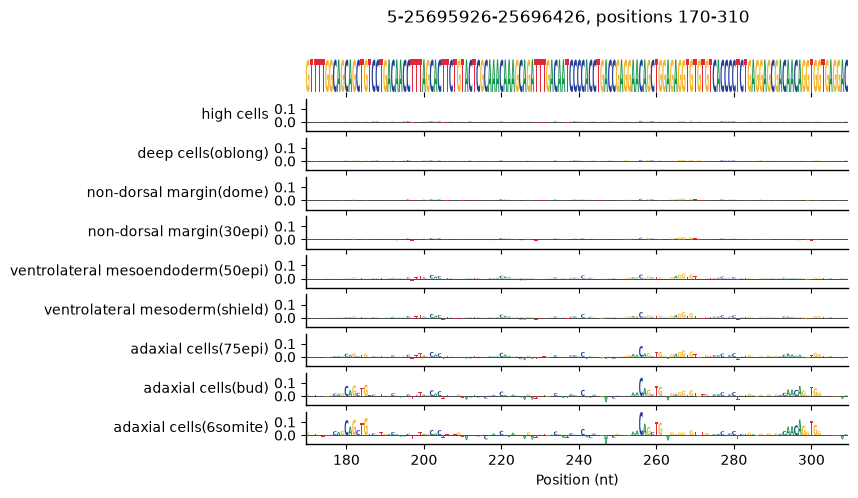

In [7]:
fig = plot.contribution_logos(
    seq,
    contribs.loc[CELL_STATES_TO_PLOT].values,
    CELL_STATES_TO_PLOT,
    start=ZOOM_START,
    end=ZOOM_END,
)
fig.suptitle(f'{PEAK_ID}, positions {ZOOM_START}-{ZOOM_END}')
pyplot.show()

## Hypothetical contributions

Hypothetical contributions indicate the contribution each of the four bases would have at each position, and are used as input for motif discovery with TF-MoDISco. Due to their size, they are not publicly available. They can be computed with `analysis/motif_discovery/compute_contributions.py` or requested from the authors, and loaded with `data.load_hypothetical_contributions(cell_state, peak_ids)`. `plot.contribution_logos` also accepts hypothetical contributions, with shape (n_cell_states, 500, 4).